In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### Loading Data & Optimization Results

In [30]:
df = pd.read_csv('data/processed/listings_segmented.csv')
optimization_results = pd.read_csv('outputs/optimization_scipy_results.csv')

print(f'Dataset: {len(df):,} listings')
print(f'Optimization results: {len(optimization_results):,} samples')

# Extracting segment-level pricing strategies
segment_strategies = optimization_results.groupby('segment')['price_change_pct'].median()

print(f'\nPricing Strategies by Segment:')
for seg, change in segment_strategies.items():
    print(f'   Segment {seg}: {change:+.2f}% price change')

Dataset: 58,736 listings
Optimization results: 300 samples

Pricing Strategies by Segment:
   Segment 0: +20.00% price change
   Segment 1: +15.00% price change
   Segment 2: +10.00% price change


### Power Analysis

**Method:** Monte Carlo simulation to estimate statistical power for different sample sizes

In [31]:
def run_power_analysis(baseline_mean, baseline_std, effect_size, sample_sizes, n_sims=500):
    """
    Estimating power via simulation
    """
    results = []
    
    for n in sample_sizes:
        significant_count = 0
        np.random.seed(42)
        
        for _ in range(n_sims):
            control = np.random.normal(baseline_mean, baseline_std, n)
            treatment = np.random.normal(baseline_mean * (1 + effect_size), baseline_std, n)
            
            _, p = ttest_ind(treatment, control)
            if p < 0.05:
                significant_count += 1
        
        power = significant_count / n_sims
        results.append({'n_per_group': n, 'power': power})
    
    return pd.DataFrame(results)

# Estimating baseline metrics
df['baseline_revenue'] = df['price'] * df['number_of_reviews'].fillna(0)
baseline_mean = df['baseline_revenue'].mean()
baseline_std = df['baseline_revenue'].std()

print(f'Baseline Metrics:')
print(f'Mean revenue: ${baseline_mean:.2f}')
print(f'Std dev: ${baseline_std:.2f}')
print(f'CV: {baseline_std/baseline_mean:.2f}')

# Runing power analysis
sample_sizes = [1000, 2000, 5000, 10000, 20000, 30000]
sample_sizes = [s for s in sample_sizes if s <= len(df)//2]

print(f'\nRunning power analysis (500 simulations per sample size)...')
power_results = run_power_analysis(
    baseline_mean=baseline_mean,
    baseline_std=baseline_std,
    effect_size=0.05,  # Targeting 5% lift
    sample_sizes=sample_sizes
)

print(f'\nPower Analysis Results:')
for _, row in power_results.iterrows():
    print(f'n={row["n_per_group"]:,}: Power={row["power"]:.1%}')

# Recommendation
adequate = power_results[power_results['power'] >= 0.80]
if len(adequate) > 0:
    rec_n = adequate.iloc[0]['n_per_group']
    print(f'\nRecommended: {rec_n:,} per group for 80% power')
else:
    print(f'\nNeed larger sample for 80% power')

# Decision: Will use full dataset
actual_n = len(df) // 2
print(f'\nDecision: Use full dataset ({actual_n:,} per group)')
print(f'Rationale: Simulation environment, maximize power')

Baseline Metrics:
Mean revenue: $3920.36
Std dev: $9504.91
CV: 2.42

Running power analysis (500 simulations per sample size)...

Power Analysis Results:
n=1,000.0: Power=7.6%
n=2,000.0: Power=10.0%
n=5,000.0: Power=17.0%
n=10,000.0: Power=27.8%
n=20,000.0: Power=50.8%

Need larger sample for 80% power

Decision: Use full dataset (29,368 per group)
Rationale: Simulation environment, maximize power


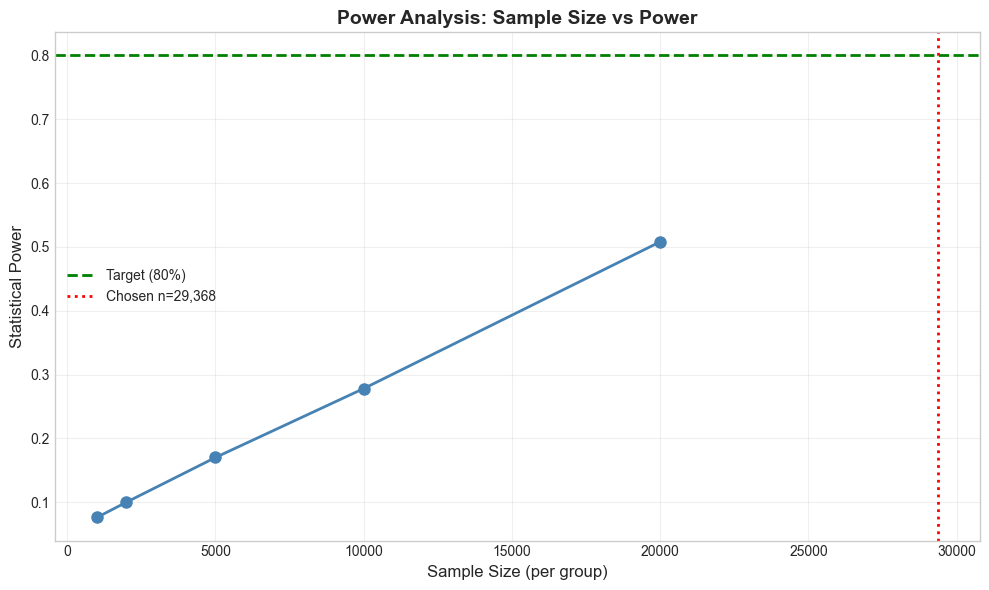

Saved: power_analysis.png


In [32]:
# Visualizing power curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(power_results['n_per_group'], power_results['power'], 
        'o-', linewidth=2, markersize=8, color='steelblue')
ax.axhline(0.80, color='green', linestyle='--', linewidth=2, label='Target (80%)')
ax.axvline(actual_n, color='red', linestyle=':', linewidth=2, label=f'Chosen n={actual_n:,}')

ax.set_xlabel('Sample Size (per group)', fontsize=12)
ax.set_ylabel('Statistical Power', fontsize=12)
ax.set_title('Power Analysis: Sample Size vs Power', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/power_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: power_analysis.png')

### Assigning A/B Groups & Applying Treatment

In [20]:
# Stratified randomization by segment
np.random.seed(42)
df['group'] = None

for seg in df['segment'].unique():
    seg_idx = df[df['segment'] == seg].index
    shuffled = np.random.permutation(seg_idx)
    n_control = len(shuffled) // 2
    
    df.loc[shuffled[:n_control], 'group'] = 'control'
    df.loc[shuffled[n_control:], 'group'] = 'treatment'

print(f'Group Assignment:')
print(f'Control:   {(df.group=="control").sum():,}')
print(f'Treatment: {(df.group=="treatment").sum():,}')

# Apply pricing strategies
df['optimal_price'] = df['price'] * (1 + df['segment'].map(segment_strategies) / 100)
df['test_price'] = df.apply(
    lambda x: x['price'] if x['group'] == 'control' else x['optimal_price'], axis=1
)

print(f'\nTreatment: {df[df.group=="treatment"]["test_price"].median() / df[df.group=="control"]["test_price"].median() - 1:.1%} median price increase')

Group Assignment:
Control:   29,367
Treatment: 29,369

Treatment: 10.9% median price increase


### Simulating Outcomes

In [21]:
# Simulating demand with elasticity
def simulate_demand(row):
    baseline = row['number_of_reviews']
    
    if row['group'] == 'control':
        return baseline * (1 + np.random.normal(0, 0.05))
    else:
        price_change = (row['test_price'] - row['price']) / row['price']
        elasticity = row.get('elasticity', -0.24)
        demand_change = elasticity * price_change
        return max(baseline * (1 + demand_change + np.random.normal(0, 0.05)), 0)

np.random.seed(42)
df['simulated_demand'] = df.apply(simulate_demand, axis=1)
df['simulated_revenue'] = df['test_price'] * df['simulated_demand']

### Statistical Significance

In [22]:
control = df[df['group'] == 'control']['simulated_revenue']
treatment = df[df['group'] == 'treatment']['simulated_revenue']

# Summary stats
control_mean = control.mean()
treatment_mean = treatment.mean()
abs_lift = treatment_mean - control_mean
rel_lift = (abs_lift / control_mean) * 100

print(f'\nSummary Statistics:')
print(f'Control mean:   ${control_mean:.2f}')
print(f'Treatment mean: ${treatment_mean:.2f}')
print(f'Absolute lift:  ${abs_lift:+.2f}')
print(f'Relative lift:  {rel_lift:+.2f}%')

# Welch's t-test
t_stat, p_value = ttest_ind(treatment, control, equal_var=False)
is_significant = p_value < 0.05

print(f'\nWelch\'s t-test:')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Result: {"Significant" if is_significant else "Not significant"} (α=0.05)')

# Effect size
pooled_std = np.sqrt((control.std()**2 + treatment.std()**2) / 2)
cohens_d = abs_lift / pooled_std
effect_size = 'Small' if cohens_d < 0.5 else ('Medium' if cohens_d < 0.8 else 'Large')

print(f'\nEffect Size:')
print(f'Cohen\'s d: {cohens_d:.3f} ({effect_size})')

# Bootstrap CI
print(f'\nBootstrap Confidence Interval (1000 iterations)...')
np.random.seed(42)
bootstrap_lifts = []

for _ in range(1000):
    c_sample = np.random.choice(control, len(control), replace=True)
    t_sample = np.random.choice(treatment, len(treatment), replace=True)
    lift = ((t_sample.mean() - c_sample.mean()) / c_sample.mean()) * 100
    bootstrap_lifts.append(lift)

ci_lower = np.percentile(bootstrap_lifts, 2.5)
ci_upper = np.percentile(bootstrap_lifts, 97.5)

print(f'95% CI: [{ci_lower:.2f}%, {ci_upper:.2f}%]')
print(f'Interpretation: {"Excludes zero" if ci_lower > 0 else "Includes zero"}')


Summary Statistics:
Control mean:   $3972.66
Treatment mean: $4211.23
Absolute lift:  $+238.56
Relative lift:  +6.01%

Welch's t-test:
t-statistic: 2.8822
p-value: 0.0040
Result: Significant (α=0.05)

Effect Size:
Cohen's d: 0.024 (Small)

Bootstrap Confidence Interval (1000 iterations)...
95% CI: [1.87%, 10.34%]
Interpretation: Excludes zero


### Practical Significance

In [23]:
# Business criteria
is_positive = rel_lift > 0
is_substantial = abs(rel_lift) > 2.0  # >2% lift
ci_reliable = ci_lower > 0

print(f'\nDecision Criteria:')
print(f'Statistical significance: {"Pass" if is_significant else "Fail"}')
print(f'Positive lift: {"Pass" if is_positive else "Fail"}')
print(f'Substantial (>2%): {"Pass" if is_substantial else "Fail"}')
print(f'CI excludes zero: {"Pass" if ci_reliable else "Fail"}')

# Final decision
should_rollout = is_significant and is_positive and is_substantial

print(f'\nRecommendation: ', end='')
if should_rollout:
    print('Rollout')
    print(f'Impact: {rel_lift:+.2f}% revenue lift (${abs_lift:+.2f} per listing)')
elif is_positive:
    print('Monitor')
    print(f'Positive signal but not conclusive')
else:
    print('Do Not Rollout')
    print(f'Negative or insignificant impact')


Decision Criteria:
Statistical significance: Pass
Positive lift: Pass
Substantial (>2%): Pass
CI excludes zero: Pass

Recommendation: Rollout
Impact: +6.01% revenue lift ($+238.56 per listing)


### Segment-Level Analysis

In [24]:
print('\nSegment-Level Results:')
segment_results = []

for seg in sorted(df['segment'].unique()):
    seg_data = df[df['segment'] == seg]
    c = seg_data[seg_data['group'] == 'control']['simulated_revenue']
    t = seg_data[seg_data['group'] == 'treatment']['simulated_revenue']
    
    seg_lift = ((t.mean() - c.mean()) / c.mean()) * 100
    _, p = ttest_ind(t, c, equal_var=False) if len(c) > 1 and len(t) > 1 else (np.nan, 1.0)
    
    segment_results.append({
        'segment': seg,
        'lift_%': seg_lift,
        'p_value': p,
        'significant': p < 0.05
    })
    
    print(f'Seg {seg}: {seg_lift:+.2f}% (p={p:.4f}) {"Good to rollout" if p < 0.05 else "Don't rollout"}')

segment_df = pd.DataFrame(segment_results)


Segment-Level Results:
Seg 0: +9.66% (p=0.0254) Good to rollout
Seg 1: +14.57% (p=0.0263) Good to rollout
Seg 2: +4.77% (p=0.0469) Good to rollout


### Visualizations

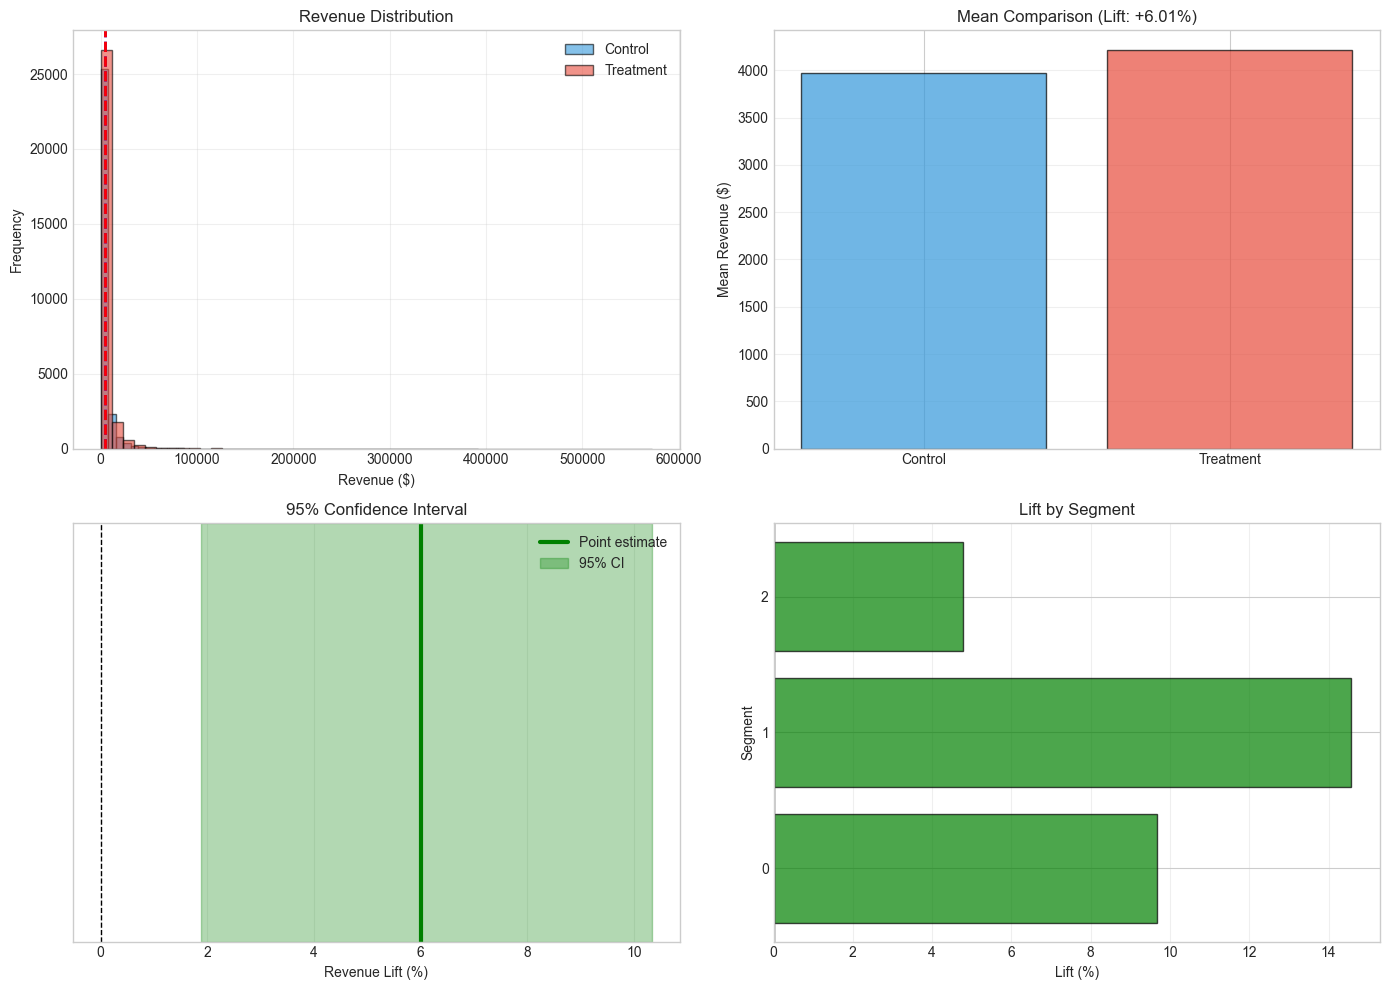

Saved: ab_test_results.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue distribution
axes[0, 0].hist(control, bins=50, alpha=0.6, label='Control', color='#3498db', edgecolor='black')
axes[0, 0].hist(treatment, bins=50, alpha=0.6, label='Treatment', color='#e74c3c', edgecolor='black')
axes[0, 0].axvline(control_mean, color='blue', linestyle='--', linewidth=2)
axes[0, 0].axvline(treatment_mean, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Revenue ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Revenue Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Mean comparison
axes[0, 1].bar(['Control', 'Treatment'], [control_mean, treatment_mean],
               color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Mean Revenue ($)')
axes[0, 1].set_title(f'Mean Comparison (Lift: {rel_lift:+.2f}%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Confidence interval
axes[1, 0].axvline(rel_lift, color='green', linewidth=3, label='Point estimate')
axes[1, 0].axvspan(ci_lower, ci_upper, alpha=0.3, color='green', label='95% CI')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Revenue Lift (%)')
axes[1, 0].set_title('95% Confidence Interval')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yticks([])

# 4. Segment results
colors = ['green' if x > 0 else 'red' for x in segment_df['lift_%']]
axes[1, 1].barh(segment_df['segment'].astype(str), segment_df['lift_%'],
                color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(0, color='black', linewidth=1)
axes[1, 1].set_xlabel('Lift (%)')
axes[1, 1].set_ylabel('Segment')
axes[1, 1].set_title('Lift by Segment')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/ab_test_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ab_test_results.png')

### Saving Results

In [26]:
# Summary
summary = pd.DataFrame([{
    'control_mean': control_mean,
    'treatment_mean': treatment_mean,
    'absolute_lift': abs_lift,
    'relative_lift_%': rel_lift,
    'ci_lower_%': ci_lower,
    'ci_upper_%': ci_upper,
    'p_value': p_value,
    'cohens_d': cohens_d,
    'is_significant': is_significant,
    'recommendation': 'ROLLOUT' if should_rollout else ('MONITOR' if is_positive else 'DO_NOT_ROLLOUT')
}])

summary.to_csv('outputs/ab_test_summary.csv', index=False)
segment_df.to_csv('outputs/ab_test_segments.csv', index=False)
power_results.to_csv('outputs/power_analysis_results.csv', index=False)

print('Saved: ab_test_summary.csv')
print('Saved: ab_test_segments.csv')
print('Saved: power_analysis_results.csv')

# Json report
import json

report = {
    'test_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'sample_size': {'control': len(control), 'treatment': len(treatment)},
    'results': {
        'relative_lift_%': float(rel_lift),
        'ci_95%': [float(ci_lower), float(ci_upper)],
        'p_value': float(p_value),
        'cohens_d': float(cohens_d)
    },
    'decision': {
        'is_significant': bool(is_significant),
        'is_substantial': bool(is_substantial),
        'recommendation': summary['recommendation'].values[0]
    }
}

with open('outputs/ab_test_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Saved: ab_test_report.json')

Saved: ab_test_summary.csv
Saved: ab_test_segments.csv
Saved: power_analysis_results.csv
Saved: ab_test_report.json


## Summary

In [28]:
print(f'\nKey Results:')
print(f'Revenue lift: {rel_lift:+.2f}% (95% CI: [{ci_lower:.2f}%, {ci_upper:.2f}%])')
print(f'Significance: {f"p={p_value:.4f}" if is_significant else f"p={p_value:.4f}"}')
print(f'Effect size:  {cohens_d:.3f} ({effect_size})')
print(f'\nRecommendation: {report["decision"]["recommendation"]}')

print('\nProject Complete - All notebooks finished')


Key Results:
Revenue lift: +6.01% (95% CI: [1.87%, 10.34%])
Significance: p=0.0040
Effect size:  0.024 (Small)

Recommendation: ROLLOUT

Project Complete - All notebooks finished
